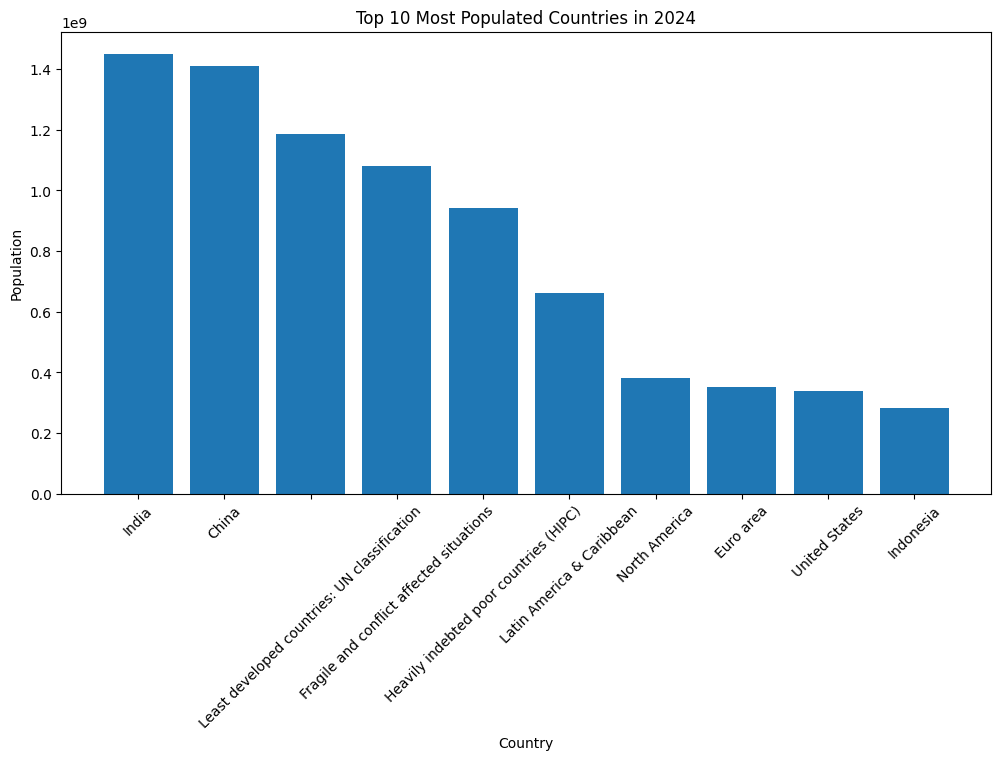

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# Extract ZIP file
zip_path = '/content/API_SP.POP.TOTL_DS2_en_csv_v2_127039.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/population_data')

# Load CSV file
file_path = '/content/population_data/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv'

df = pd.read_csv(file_path, skiprows=4)

# Select country and 2024 population
population_2024 = df[['Country Name', '2024']]

# Remove missing values
population_2024 = population_2024.dropna()

# Convert population to numeric
population_2024['2024'] = pd.to_numeric(population_2024['2024'])

# Get top 10 populated countries
exclude_keywords = ['income', 'IBRD', 'IDA', 'dividend',
                    'OECD', 'Asia', 'Europe', 'Africa',
                    'World', 'members']

population_2024 = population_2024[
    ~population_2024['Country Name'].str.contains(
        '|'.join(exclude_keywords),
        case=False,
        na=False
    )
]

top10 = population_2024.sort_values(by='2024', ascending=False).head(10)
# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(top10['Country Name'], top10['2024'])

plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Population')
plt.title('Top 10 Most Populated Countries in 2024')

plt.show()